# Task 1: Logistic Regression for Binary Classification

Goal: Build a logistic regression model to predict customer churn.

Objectives:
- Load and preprocess the dataset.
- Train a logistic regression model.
- Interpret coefficients and odds ratios.
- Evaluate the model using accuracy, precision, recall, and ROC curve.

In [47]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

## Step 1: Load the Dataset

First, we load the original churn dataset using pandas.

In [48]:
# Load the dataset

df = pd.read_csv('dataset/bigml_original_churn.csv')

df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


The dataset contains telecom customer information. The target column is **`Churn`**, where:

- `0` means the customer did **not** churn.
- `1` means the customer **did** churn.

In [49]:
# View the dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   str    
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   str    
 4   international plan      3333 non-null   str    
 5   voice mail plan         3333 non-null   str    
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   int64  
 15

In [50]:
# Descriptive statistics of the dataset

df.describe().T

,count,mean,std,min,25%,50%,75%,max
account length,3333.0,101.064806,39.822106,1.00,74.00,101.00,127.00,243.00
area code,3333.0,437.182418,42.371290,408.00,408.00,415.00,510.00,510.00
number vmail messages,3333.0,8.099010,13.688365,0.00,0.00,0.00,20.00,51.00
total day minutes,3333.0,179.775098,54.467389,0.00,143.70,179.40,216.40,350.80
total day calls,3333.0,100.435644,20.069084,0.00,87.00,101.00,114.00,165.00
total day charge,3333.0,30.562307,9.259435,0.00,24.43,30.50,36.79,59.64
total eve minutes,3333.0,200.980348,50.713844,0.00,166.60,201.40,235.30,363.70
total eve calls,3333.0,100.114311,19.922625,0.00,87.00,100.00,114.00,170.00
total eve charge,3333.0,17.083540,4.310668,0.00,14.16,17.12,20.00,30.91
total night minutes,3333.0,200.872037,50.573847,23.20,167.00,201.20,235.30,395.00


## Step 2: Check for Missing Values

Before training the model, we need to check whether the dataset contains missing values.

In [51]:
# Check for missing values

df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

The dataset does not contain missing values. However, we will still include imputation inside the preprocessing pipeline to make the model more reliable.

## Step 3: Check the Target Variable

The target variable is `churn`.

We need to see how many customers churned and how many did not churn.

In [52]:
# Check the distribution of the target variable

df["churn"].value_counts()

churn
False    2850
True      483
Name: count, dtype: int64

In [53]:
# Show percentage distribution of the target variable

print(round(df["churn"].value_counts(normalize=True) * 100, 2).astype(str) + "%")

churn
False    85.51%
True     14.49%
Name: proportion, dtype: str


The target variable is imbalanced because most customers did not churn.

This means accuracy alone may not be enough to evaluate the model. We also need precision, recall, F1-score, and ROC-AUC.

## Step 4: Prepare Features and Target

The target variable is `churn`.

The `phone number` column should be removed because it is only an identifier and does not help the model predict customer churn.

The `area code` column is converted to text because it is a category, not a continuous numerical value.


In [54]:
# Prepare the features and target variable

X = df.drop(["churn", "phone number"], axis=1)
y = df["churn"].astype(int)

X["area code"] = X["area code"].astype(str)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3333, 19)
Target shape: (3333,)


In [55]:
# Show the first few rows of the features
X.head()

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


## Step 5: Identify Numerical and Categorical Features

Numerical features need scaling.

Categorical features need encoding because machine learning models cannot directly work with text values.

In [56]:
# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['account length', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls']

Categorical features:
['state', 'area code', 'international plan', 'voice mail plan']


## Step 6: Split the Dataset

We split the original dataset into training and testing sets.

I will use `stratify=y` to keep the same churn ratio in both training and testing sets.

In [57]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2666, 19)
X_test shape: (667, 19)
y_train shape: (2666,)
y_test shape: (667,)


## Step 7: Build the Preprocessing Pipeline

The preprocessing pipeline will:

1. Fill missing numerical values using the median.
2. Standardize numerical features.
3. Fill missing categorical values using the most frequent value.
4. Convert categorical features into numeric format using one-hot encoding.

In [58]:
# Preprocessing pipelines for numerical and categorical features

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Step 8: Train the Logistic Regression Model

Logistic regression is used for binary classification.

The model predicts the probability that a customer belongs to class `1`, which means the customer churned.

We use `class_weight="balanced"` because the dataset is imbalanced.

In [59]:
# Build and train the model

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


## Step 9: Make Predictions

After training the model, we use it to make predictions on the test set.

In [60]:
# Model predictions

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Predictions completed.")
print("y_pred shape:", y_pred.shape)
print("y_proba shape:", y_proba.shape)

Predictions completed.
y_pred shape: (667,)
y_proba shape: (667,)


## Step 10: Evaluate the Model

We evaluate the model using several classification metrics.

Accuracy shows the percentage of correct predictions.

Precision shows how many predicted churn customers actually churned.

Recall shows how many actual churn customers were correctly identified.

F1-score balances precision and recall.

In [61]:
# Evaluate the model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Accuracy: 0.7496
Precision: 0.3317
Recall: 0.7113
F1-score: 0.4525
ROC-AUC: 0.8042


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84       570
           1       0.33      0.71      0.45        97

    accuracy                           0.75       667
   macro avg       0.64      0.73      0.65       667
weighted avg       0.85      0.75      0.78       667



## Step 11: Confusion Matrix

The confusion matrix shows:

- True Negatives: correctly predicted non-churn customers
- False Positives: non-churn customers incorrectly predicted as churn
- False Negatives: churn customers incorrectly predicted as non-churn
- True Positives: correctly predicted churn customers

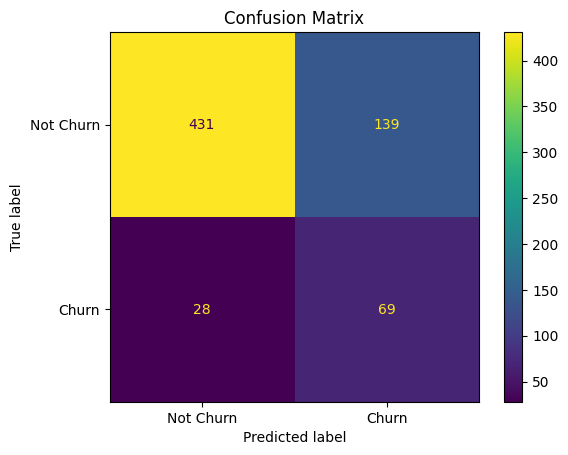

In [63]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Step 12: ROC Curve

The ROC curve shows the relationship between the true positive rate and the false positive rate.

The ROC-AUC score measures how well the model separates churn customers from non-churn customers.

A higher ROC-AUC score means better classification performance.

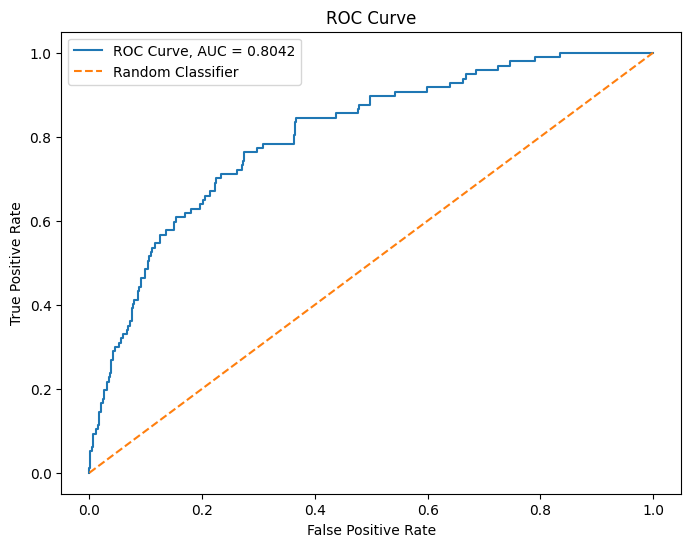

In [64]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve, AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step 13: Interpret Model Coefficients

Logistic regression coefficients explain how each feature affects the log-odds of churn.

A positive coefficient means the feature increases the probability of churn.

A negative coefficient means the feature decreases the probability of churn.

The odds ratio is calculated using:

`odds ratio = e ^ coefficient`

Interpretation:

- Odds ratio greater than 1 means higher odds of churn.
- Odds ratio less than 1 means lower odds of churn.
- Odds ratio equal to 1 means no effect.

In [65]:
# Feature Importance

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "odds_ratio": np.exp(coefficients)
    }
)

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient,odds_ratio
19,cat__state_CA,1.299006,3.665650
70,cat__international plan_yes,1.195693,3.305849
41,cat__state_MT,1.165962,3.209010
71,cat__voice mail plan_no,1.054143,2.869516
55,cat__state_SC,0.894756,2.446738
14,num__customer service calls,0.840594,2.317744
46,cat__state_NJ,0.680953,1.975759
1,num__number vmail messages,0.604396,1.830146
40,cat__state_MS,0.568642,1.765868
58,cat__state_TX,0.563341,1.756531


In [66]:
print("Top 10 features that increase churn probability:")
coef_df.head(10)

Top 10 features that increase churn probability:


,feature,coefficient,odds_ratio
19,cat__state_CA,1.299006,3.665650
70,cat__international plan_yes,1.195693,3.305849
41,cat__state_MT,1.165962,3.209010
71,cat__voice mail plan_no,1.054143,2.869516
55,cat__state_SC,0.894756,2.446738
14,num__customer service calls,0.840594,2.317744
46,cat__state_NJ,0.680953,1.975759
1,num__number vmail messages,0.604396,1.830146
40,cat__state_MS,0.568642,1.765868
58,cat__state_TX,0.563341,1.756531


In [67]:
print("Top 10 features that decrease churn probability:")
coef_df.tail(10)

Top 10 features that decrease churn probability:


,feature,coefficient,odds_ratio
29,cat__state_IL,-0.593264,0.552521
16,cat__state_AL,-0.704719,0.494247
65,cat__state_WY,-0.712650,0.490343
44,cat__state_NE,-0.737874,0.478129
57,cat__state_TN,-0.761376,0.467023
61,cat__state_VT,-0.981991,0.374565
72,cat__voice mail plan_yes,-1.128057,0.323662
60,cat__state_VA,-1.136235,0.321025
69,cat__international plan_no,-1.269607,0.280942
26,cat__state_HI,-1.367547,0.254731


## Step 14: Coefficient Interpretation

The features with the largest positive coefficients increase the probability of churn.

The features with the most negative coefficients decrease the probability of churn.

For numerical features, the coefficient represents the effect after standardization.

For categorical features, the coefficient represents the effect of that category after one-hot encoding.

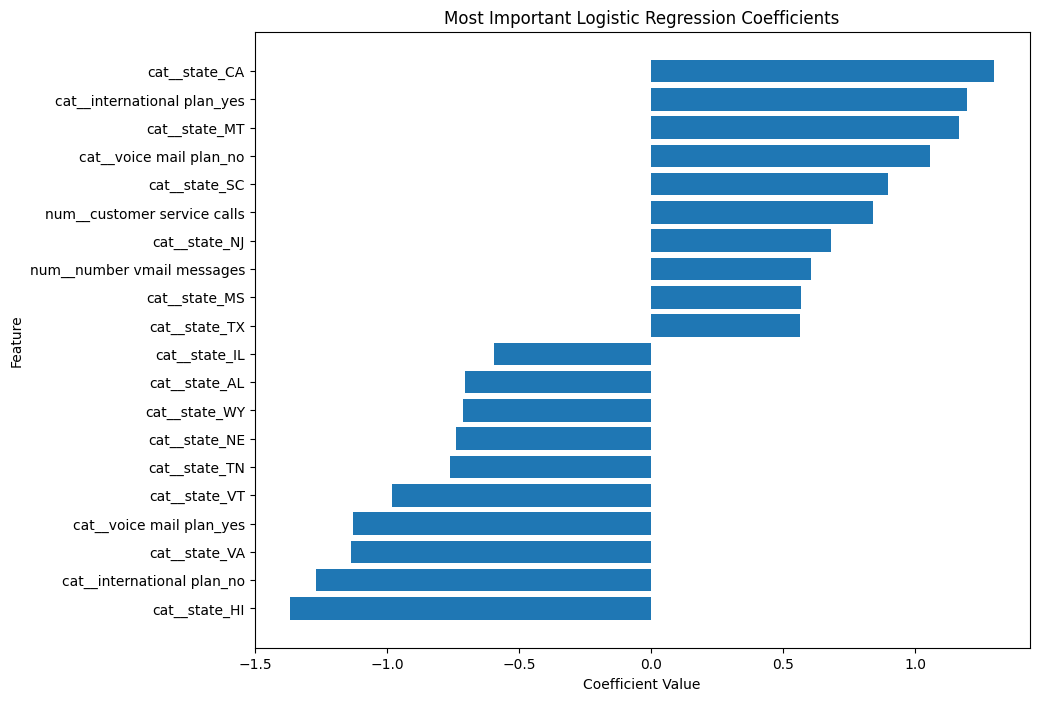

In [68]:
# Visualize the top positive and negative coefficients

top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)

top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Most Important Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.show()

## Step 15: Final Conclusion

In this project, we built a logistic regression model to predict customer churn.

The original dataset was loaded and split manually into training and testing sets.

The data was preprocessed using a pipeline that handled numerical and categorical features separately.

The logistic regression model was trained using scikit-learn.

The model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC curve, and ROC-AUC score.

The coefficients and odds ratios were also analyzed to understand which features increase or decrease the probability of churn.

In [69]:
print("Final Model Performance")
print("-----------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Final Model Performance
-----------------------
Accuracy: 0.7496
Precision: 0.3317
Recall: 0.7113
F1-score: 0.4525
ROC-AUC: 0.8042


I used the original unsplit telecom churn dataset. 
Instead of using pre-split CSV files, I manually separated the dataset into training and testing sets using train_test_split.

The target variable was churn, which was converted from True/False into 1/0.

I removed phone number because it is only an identifier.

I used one-hot encoding for categorical variables and standardization for numerical variables.

Then I trained a logistic regression model and evaluated it using accuracy, precision, recall, F1-score, confusion matrix, and ROC curve.

Finally, I interpreted the model coefficients and odds ratios to understand which features increase or decrease the probability of churn.